# SweetTV - TV Program Recommender (LightFM BPR)

Notebook end-to-end cho Kaggle “SweetTV - TV Program recommender” theo hướng **giống BPR_python3.11 nhất**:

- **Model:** LightFM với `loss='bpr'` (pairwise ranking, SGD)
- **Implicit feedback:** `screen_time` (0–1)
- **Filter bắt buộc:** loại `tv_show_id == 0` khỏi train/val/test
- **Track loss:** tính **proxy BPR loss** (sampling) cho cả train & val theo epoch và vẽ biểu đồ
- **Offline evaluation:** Precision / Recall / F1 / NDCG / MAP @K (default K=5)
- **Submission:** recommend **chỉ trong candidate set** từ `metadata_test.parquet`, và **KHÔNG filter seen** khi submit (giống cách thường giúp tăng public score)

**Input paths mặc định**
- `/content/logs_train.parquet`
- `/content/logs_val.parquet`
- `/content/metadata_test.parquet`
- `/content/submission.csv`

**Output**
- Plot loss train/val theo epoch
- Bảng metrics trên val
- `/content/submission_bpr_lightfm.csv`


## 1) Setup

Cài thư viện cần thiết và import:
- Sử dụng python 3.11 (phiên bản 07.2025 Colab)
- `lightfm` (BPR SGD)
- `pandas`, `numpy`, `scipy.sparse`
- `matplotlib` để plot loss
- `tqdm` để progress bar

Thiết lập:
- seed để tái lập
- các hyperparameters chính (latent dim, lr, reg, epochs)
- cấu hình quan trọng theo style BPR_python3.11:
  - `USE_BINARY_INTERACTIONS=True`
  - `SUBMISSION_FILTER_SEEN=False`
  - `USE_CANDIDATE_FILTER_SUBMIT=True`


In [ ]:
!pip -q install lightfm tqdm pyarrow

import os, time, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy import sparse
import matplotlib.pyplot as plt

from lightfm import LightFM
from lightfm.data import Dataset

# =========================
# CONFIG (edit here)
# =========================
SEED = 42
K = 5
THRESH = 0.5                    # threshold để định nghĩa GT positive trên VAL
GT_AGG = "mean"                 # "mean" hoặc "max" screen_time để xét GT

# ---- giống BPR_python3.11 nhất ----
USE_BINARY_INTERACTIONS = True  # True thường score Kaggle tốt hơn
SUBMISSION_FILTER_SEEN = False  # quan trọng: KHÔNG filter seen khi submit

# ---- có thể thử tune ----
NO_COMPONENTS = 128             # latent dim (64/128/256)
LEARNING_RATE = 0.05
ITEM_ALPHA = 1e-6               # regularization (L2)
USER_ALPHA = 1e-6
EPOCHS = 20
NUM_THREADS = 4

# ---- proxy loss sampling ----
LOSS_SAMPLES_TRAIN = 12000
LOSS_SAMPLES_VAL   = 12000

# ---- candidate filtering ----
USE_CANDIDATE_FILTER_EVAL = False   # thường False (eval trên toàn bộ items)
USE_CANDIDATE_FILTER_SUBMIT = True  # True (submit chỉ trong metadata_test)

# ---- aggregation cho interaction weight nếu không binary ----
AGG_MODE = "sum"                # "sum" hoặc "mean" trên screen_time để làm weight

# Paths (Colab default)
PATH_TRAIN = "/content/drive/MyDrive/Project/TV_Recommender/preprocessed_data2/logs_train.parquet"
PATH_VAL   =  "/content/drive/MyDrive/Project/TV_Recommender/preprocessed_data2/logs_val.parquet"
PATH_META  =  "/content/drive/MyDrive/Project/TV_Recommender/preprocessed_data2/metadata_test.parquet"
PATH_SUB   = "/content/drive/MyDrive/Project/TV_Recommender/data/submission.csv"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

class Timer:
    def __init__(self, name=""):
        self.name = name
    def __enter__(self):
        self.t0 = time.time()
        return self
    def __exit__(self, exc_type, exc, tb):
        print(f"[TIMER] {self.name}: {time.time()-self.t0:.2f}s")

set_seed(SEED)
print("Setup done. Seed =", SEED)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Setup done. Seed = 42


## 3) Load dữ liệu + thống kê nhanh

Đọc:
- `logs_train.parquet`
- `logs_val.parquet`
- `metadata_test.parquet`
- `submission.csv`

In thống kê:
- số dòng
- số user unique
- số item unique (loại `tv_show_id==0`)
- % `tv_show_id==0`
- thống kê `screen_time`

Tạo candidate set từ `metadata_test` (lọc `tv_show_id!=0`) để dùng khi generate submission.


In [ ]:
def must_exist(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}")

for p in [PATH_TRAIN, PATH_VAL, PATH_META, PATH_SUB]:
    must_exist(p)

with Timer("Load data"):
    train_df = pd.read_parquet(PATH_TRAIN)
    val_df   = pd.read_parquet(PATH_VAL)
    meta_df  = pd.read_parquet(PATH_META)
    sub_df   = pd.read_csv(PATH_SUB)

print("train:", train_df.shape, "val:", val_df.shape, "meta:", meta_df.shape, "sub:", sub_df.shape)

def print_log_stats(df, name):
    df = df.copy()
    df["tv_show_id"] = df["tv_show_id"].astype("int64")
    pct0 = (df["tv_show_id"]==0).mean()*100
    df2 = df[df["tv_show_id"]!=0]
    print(f"\n[{name}] rows={len(df):,}")
    print("  users:", df["user_id"].nunique())
    print("  items (!=0):", df2["tv_show_id"].nunique())
    print("  % tv_show_id==0:", f"{pct0:.2f}%")
    if "screen_time" in df.columns:
        st = df["screen_time"].astype(float)
        print("  screen_time:", {"min": float(st.min()), "mean": float(st.mean()), "p50": float(st.median()), "max": float(st.max())})

print_log_stats(train_df, "TRAIN")
print_log_stats(val_df, "VAL")

meta_df["tv_show_id"] = meta_df["tv_show_id"].astype("int64")
candidate_tv = meta_df.loc[meta_df["tv_show_id"]!=0, "tv_show_id"].unique().tolist()
candidate_tv_set = set(candidate_tv)
print("\nCandidate items from metadata_test (tv_show_id!=0):", len(candidate_tv))


[TIMER] Load data: 11.84s
train: (1878969, 10) val: (525983, 10) meta: (1295378, 9) sub: (1260, 2)

[TRAIN] rows=1,878,969
  users: 4868
  items (!=0): 3716
  % tv_show_id==0: 50.41%
  screen_time: {'min': 0.03570601851851852, 'mean': 0.7459944728485087, 'p50': 0.8318181818181818, 'max': 1.0}

[VAL] rows=525,983
  users: 4720
  items (!=0): 1897
  % tv_show_id==0: 50.22%
  screen_time: {'min': 0.08281786941580756, 'mean': 0.7996875445336327, 'p50': 1.0, 'max': 1.0}

Candidate items from metadata_test (tv_show_id!=0): 6636


## 4) Preprocess & Aggregate interactions

- Loại bỏ `tv_show_id == 0`
- Aggregate theo `(user_id, tv_show_id)`:
  - nếu `USE_BINARY_INTERACTIONS=True` thì mô hình sẽ coi interaction là 1/0 (đã tương tác)
  - nếu `USE_BINARY_INTERACTIONS=False` thì dùng weight (vd `sum(screen_time)` hoặc `mean(screen_time)`)

Lưu ý:
- LightFM BPR thường hoạt động tốt với binary interactions trong bài này.


In [ ]:
def filter_nonzero(df):
    df = df.copy()
    df["tv_show_id"] = df["tv_show_id"].astype("int64")
    return df[df["tv_show_id"] != 0]

train_f = filter_nonzero(train_df)
val_f   = filter_nonzero(val_df)

def aggregate_edges(df, agg_mode="sum"):
    """
    aggregate per (user_id, tv_show_id)
    return columns: user_id, tv_show_id, w (float32)
    """
    if agg_mode == "sum":
        g = df.groupby(["user_id","tv_show_id"], as_index=False)["screen_time"].sum()
    elif agg_mode == "mean":
        g = df.groupby(["user_id","tv_show_id"], as_index=False)["screen_time"].mean()
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")
    g = g.rename(columns={"screen_time":"w"})
    g["w"] = g["w"].astype(np.float32)
    return g

train_edges = aggregate_edges(train_f, AGG_MODE)
val_edges   = aggregate_edges(val_f, AGG_MODE)

print("train_edges:", train_edges.shape, "val_edges:", val_edges.shape)
print("train_edges w stats:", train_edges["w"].describe().to_dict())


train_edges: (397840, 3) val_edges: (154720, 3)
train_edges w stats: {'count': 397840.0, 'mean': 1.6570422649383545, 'std': 6.051971912384033, 'min': 0.0743425041437149, '25%': 0.42157894372940063, '50%': 0.7192592620849609, '75%': 1.0, 'max': 693.1227416992188}


## 5) Build mapping + interactions matrix (CSR)

Tạo mapping theo **TRAIN** (warm-start):

- `Dataset.fit(users_train, items_train)`
- Build `interactions_train` (CSR)
- Build `interactions_val` (CSR) nhưng chỉ giữ những user/item có trong mapping train

Báo cáo:
- số phần tử nnz
- số edge bị drop do cold-user/cold-item (đặc biệt ở VAL)
- số cold-items xuất hiện ở VAL nhưng không có trong TRAIN


In [ ]:
# ===== Build mapping on TRAIN only (warm mapping) =====
dataset = Dataset()
with Timer("Dataset.fit (TRAIN mapping)"):
    dataset.fit(
        users=train_edges["user_id"].unique(),
        items=train_edges["tv_show_id"].unique()
    )

(user_id_map, user_feat_map, item_id_map, item_feat_map) = dataset.mapping()
n_users = len(user_id_map)
n_items = len(item_id_map)
print("n_users:", n_users, "n_items:", n_items)

def build_interactions_from_edges(edges_df, use_binary=True):
    # Keep warm only
    df = edges_df[edges_df["user_id"].isin(user_id_map.keys()) &
                  edges_df["tv_show_id"].isin(item_id_map.keys())].copy()
    dropped = len(edges_df) - len(df)

    if use_binary:
        it = ((u, i, 1.0) for (u, i) in zip(df["user_id"].tolist(), df["tv_show_id"].tolist()))
        interactions, weights = dataset.build_interactions(it)
        # weights from build_interactions will be all 1.0; keep it for consistency
    else:
        it = ((u, i, float(w)) for (u, i, w) in zip(df["user_id"].tolist(), df["tv_show_id"].tolist(), df["w"].tolist()))
        interactions, weights = dataset.build_interactions(it)

    return interactions.tocsr(), weights.tocsr(), dropped

with Timer("Build interactions TRAIN"):
    interactions_train, weights_train, dropped_tr = build_interactions_from_edges(train_edges, use_binary=USE_BINARY_INTERACTIONS)
print("interactions_train:", interactions_train.shape, "nnz:", interactions_train.nnz, "dropped:", dropped_tr)

with Timer("Build interactions VAL (warm items only)"):
    interactions_val, weights_val, dropped_val = build_interactions_from_edges(val_edges, use_binary=USE_BINARY_INTERACTIONS)
print("interactions_val:", interactions_val.shape, "nnz:", interactions_val.nnz, "dropped:", dropped_val)

# Cold item report in VAL
val_items_all = set(val_edges["tv_show_id"].unique().tolist())
train_items_set = set(item_id_map.keys())
cold_items = val_items_all - train_items_set
print("Cold items in VAL (not in TRAIN mapping):", len(cold_items))


[TIMER] Dataset.fit (TRAIN mapping): 0.05s
n_users: 4838 n_items: 3716
[TIMER] Build interactions TRAIN: 2.66s
interactions_train: (4838, 3716) nnz: 397840 dropped: 0
[TIMER] Build interactions VAL (warm items only): 0.76s
interactions_val: (4838, 3716) nnz: 123807 dropped: 30913
Cold items in VAL (not in TRAIN mapping): 443


## 6) Xây dựng Ground Truth (GT) trên tập VAL

Định nghĩa positive trên VAL để đánh giá offline:

- Aggregate `screen_time` theo `(user_id, tv_show_id)` bằng:
  - `GT_AGG="mean"` hoặc `GT_AGG="max"`
- Positive nếu `aggregated_screen_time >= THRESH` (mặc định 0.5)

GT_u = tập item_idx của user u (chỉ tính các item warm theo mapping train).

In báo cáo:
- số user có GT
- số GT edges
- phân bố kích thước GT per user


In [ ]:
def build_gt_from_val_raw(val_raw_df, thresh=0.5, agg="mean"):
    """
    GT_u = set(item_idx) for users where aggregated screen_time >= thresh
    only warm users/items (in train mapping)
    """
    df = val_raw_df.copy()
    df = df[df["user_id"].isin(user_id_map.keys())]
    df = df[df["tv_show_id"].isin(item_id_map.keys())]

    if agg == "mean":
        g = df.groupby(["user_id","tv_show_id"], as_index=False)["screen_time"].mean()
    elif agg == "max":
        g = df.groupby(["user_id","tv_show_id"], as_index=False)["screen_time"].max()
    else:
        raise ValueError("agg must be 'mean' or 'max'")

    g = g.rename(columns={"screen_time":"gt_score"})
    g = g[g["gt_score"] >= thresh]

    gt = {}
    for u, sub in g.groupby("user_id"):
        u_idx = user_id_map[u]
        items_idx = [item_id_map[it] for it in sub["tv_show_id"].tolist()]
        if items_idx:
            gt[u_idx] = set(items_idx)

    report = {
        "users_with_gt": len(gt),
        "total_gt_edges": int(len(g)),
        "thresh": thresh,
        "agg": agg
    }
    return gt, report

gt_val, gt_report = build_gt_from_val_raw(val_f, thresh=THRESH, agg=GT_AGG)
print("GT report:", gt_report)

sizes = [len(s) for s in gt_val.values()]
if sizes:
    print("GT size stats:", {"min": int(np.min(sizes)), "mean": float(np.mean(sizes)), "median": float(np.median(sizes)), "max": int(np.max(sizes))})


GT report: {'users_with_gt': 4530, 'total_gt_edges': 88573, 'thresh': 0.5, 'agg': 'mean'}
GT size stats: {'min': 1, 'mean': 19.55253863134658, 'median': 14.0, 'max': 163}


## 7) Proxy BPR Loss (Train + Val) bằng sampling

Vì tính full pairwise loss rất tốn, ta dùng proxy nhất quán:

Mỗi sample:
- chọn user u có ít nhất 1 positive
- chọn 1 positive item `i_pos` (từ train hoặc val)
- chọn 1 negative item `i_neg` sao cho user chưa tương tác (rejection sampling)
- score theo LightFM:
  - `s(u,i) = <U[u], V[i]> + user_bias[u] + item_bias[i]`
- loss mẫu:
  - `-log(sigmoid(s_pos - s_neg)) = softplus(-(s_pos - s_neg))`

Tính mean loss trên `LOSS_SAMPLES_*` mẫu để ra đường loss theo epoch.


In [ ]:
def softplus(x):
    return np.logaddexp(0.0, x)

def build_pos_list_from_csr(mat_csr):
    pos = []
    for u in range(mat_csr.shape[0]):
        start, end = mat_csr.indptr[u], mat_csr.indptr[u+1]
        pos.append(mat_csr.indices[start:end])
    return pos

def build_seen_sets(pos_list):
    return [set(arr.tolist()) for arr in pos_list]

train_pos_list = build_pos_list_from_csr(interactions_train)
val_pos_list   = build_pos_list_from_csr(interactions_val)

train_seen_sets = build_seen_sets(train_pos_list)
union_seen_sets = []
for u in range(n_users):
    s = set(train_seen_sets[u])
    s.update(val_pos_list[u].tolist())
    union_seen_sets.append(s)

def predict_scores_user(model, u_idx, item_indices):
    """
    score(u,i) = <U[u], V[i]> + user_bias[u] + item_bias[i]
    """
    U = model.user_embeddings
    V = model.item_embeddings
    ub = model.user_biases
    ib = model.item_biases
    return (V[item_indices] @ U[u_idx]) + ib[item_indices] + ub[u_idx]

def compute_bpr_loss_proxy(model, pos_list, seen_sets, n_samples=10000, seed=42, max_tries=50):
    rng = np.random.default_rng(seed)
    users_with_pos = np.array([u for u in range(n_users) if len(pos_list[u]) > 0], dtype=np.int32)
    if len(users_with_pos) == 0:
        return np.nan, 0

    losses = []
    used = 0
    all_items = np.arange(n_items, dtype=np.int32)

    for _ in range(n_samples):
        u = int(rng.choice(users_with_pos))
        pos_items = pos_list[u]
        i_pos = int(rng.choice(pos_items))

        seen = seen_sets[u]
        i_neg = None
        for __ in range(max_tries):
            j = int(rng.integers(0, n_items))
            if (j != i_pos) and (j not in seen):
                i_neg = j
                break
        if i_neg is None:
            continue

        s_pos = float(predict_scores_user(model, u, np.array([i_pos], dtype=np.int32))[0])
        s_neg = float(predict_scores_user(model, u, np.array([i_neg], dtype=np.int32))[0])
        diff = s_pos - s_neg
        loss = float(softplus(-diff))  # -log(sigmoid(diff))
        losses.append(loss)
        used += 1

    if used == 0:
        return np.nan, 0
    return float(np.mean(losses)), used


## 8) Train LightFM BPR theo epoch + log proxy loss

Huấn luyện bằng `fit_partial(..., epochs=1)` trong vòng lặp để:

- Train từng epoch
- Sau mỗi epoch:
  - compute `train_proxy_loss`
  - compute `val_proxy_loss`
- Lưu loss vào list để plot

Mục tiêu:
- theo dõi xu hướng loss train/val
- hỗ trợ tuning hyperparameters (dim/lr/reg/epochs)


In [ ]:
set_seed(SEED)

model = LightFM(
    loss="bpr",
    no_components=NO_COMPONENTS,
    learning_rate=LEARNING_RATE,
    item_alpha=ITEM_ALPHA,
    user_alpha=USER_ALPHA,
    random_state=SEED
)

train_loss_curve = []
val_loss_curve = []
epochs_axis = []

with Timer("Train LightFM (epoch loop)"):
    for ep in range(1, EPOCHS + 1):
        model.fit_partial(
            interactions_train,
            sample_weight=(None if USE_BINARY_INTERACTIONS else weights_train),
            epochs=1,
            num_threads=NUM_THREADS
        )

        tr_loss, tr_used = compute_bpr_loss_proxy(
            model,
            pos_list=train_pos_list,
            seen_sets=train_seen_sets,
            n_samples=LOSS_SAMPLES_TRAIN,
            seed=SEED + ep
        )

        va_loss, va_used = compute_bpr_loss_proxy(
            model,
            pos_list=val_pos_list,
            seen_sets=union_seen_sets,
            n_samples=LOSS_SAMPLES_VAL,
            seed=SEED + 10_000 + ep
        )

        epochs_axis.append(ep)
        train_loss_curve.append(tr_loss)
        val_loss_curve.append(va_loss)

        print(f"Epoch {ep:03d}/{EPOCHS} | train_proxy_loss={tr_loss:.5f} (used={tr_used}) | val_proxy_loss={va_loss:.5f} (used={va_used})")


Epoch 001/20 | train_proxy_loss=0.61148 (used=12000) | val_proxy_loss=0.57520 (used=12000)
Epoch 002/20 | train_proxy_loss=0.59601 (used=12000) | val_proxy_loss=0.56383 (used=12000)
Epoch 003/20 | train_proxy_loss=0.55933 (used=12000) | val_proxy_loss=0.52859 (used=12000)
Epoch 004/20 | train_proxy_loss=0.51667 (used=12000) | val_proxy_loss=0.50507 (used=12000)
Epoch 005/20 | train_proxy_loss=0.47806 (used=12000) | val_proxy_loss=0.48682 (used=12000)
Epoch 006/20 | train_proxy_loss=0.44434 (used=12000) | val_proxy_loss=0.48171 (used=12000)
Epoch 007/20 | train_proxy_loss=0.42640 (used=12000) | val_proxy_loss=0.47758 (used=12000)
Epoch 008/20 | train_proxy_loss=0.39894 (used=12000) | val_proxy_loss=0.48062 (used=12000)
Epoch 009/20 | train_proxy_loss=0.38010 (used=12000) | val_proxy_loss=0.47337 (used=12000)
Epoch 010/20 | train_proxy_loss=0.36930 (used=12000) | val_proxy_loss=0.47020 (used=12000)
Epoch 011/20 | train_proxy_loss=0.34827 (used=12000) | val_proxy_loss=0.47176 (used=12000)

## 9) Vẽ loss curves (Train vs Val)

Plot 2 đường:
- train proxy loss
- val proxy loss

Quan sát:
- overfitting (train giảm mạnh nhưng val không giảm)
- lựa chọn số epoch hợp lý


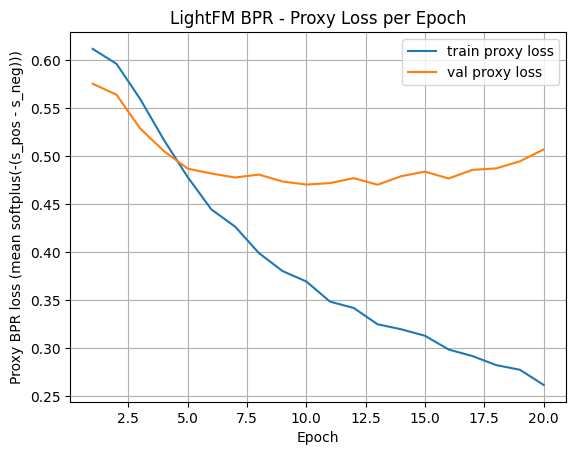

In [ ]:
plt.figure()
plt.plot(epochs_axis, train_loss_curve, label="train proxy loss")
plt.plot(epochs_axis, val_loss_curve, label="val proxy loss")
plt.xlabel("Epoch")
plt.ylabel("Proxy BPR loss (mean softplus(-(s_pos - s_neg)))")
plt.title("LightFM BPR - Proxy Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()


## 10) Recommend Top-K + Offline evaluation on VAL

Tính recommendation cho user u bằng score từ LightFM và lấy top-K.

Đánh giá trên các user có GT:
- Precision@K
- Recall@K
- F1@K
- NDCG@K
- MAP@K

Có 2 chế độ đánh giá:
1) `filter_seen=True`: không recommend item user đã tương tác trong TRAIN (đánh giá “chuẩn” CF)
2) `filter_seen=False`: gần với cách submit Kaggle (đôi khi tương quan public score tốt hơn)

Tuỳ chọn:
- `USE_CANDIDATE_FILTER_EVAL` để chỉ recommend trong candidate set (thường để False cho offline eval).


In [ ]:
def precision_at_k(rel, k): return float(np.sum(rel[:k])) / k

def recall_at_k(rel, gt_size, k):
    return float(np.sum(rel[:k])) / gt_size if gt_size > 0 else 0.0

def f1_at_k(p, r):
    return (2*p*r/(p+r)) if (p+r) > 0 else 0.0

def ndcg_at_k(rel, gt_size, k):
    denom = np.log2(np.arange(2, k+2))
    dcg = float(np.sum(rel[:k] / denom))
    ideal = np.zeros(k, dtype=np.float32)
    ideal[:min(gt_size, k)] = 1.0
    idcg = float(np.sum(ideal / denom))
    return dcg/idcg if idcg > 0 else 0.0

def map_at_k(rel, gt_size, k):
    if gt_size == 0: return 0.0
    hits, ap = 0, 0.0
    for i in range(k):
        if rel[i] == 1:
            hits += 1
            ap += hits / (i+1)
    return ap / min(gt_size, k)

# Candidate indices for eval (optional)
candidate_idx_eval = None
if USE_CANDIDATE_FILTER_EVAL:
    c = [item_id_map[t] for t in candidate_tv if t in item_id_map]
    candidate_idx_eval = np.array(c, dtype=np.int32)
    print("candidate_idx_eval:", len(candidate_idx_eval))

def batch_topk_recommendations(model, user_indices, k=5, filter_seen=True, candidate_idx=None):
    """
    Trả về dict: u_idx -> topk item_idx
    Dùng batch matmul để nhanh.
    """
    U = model.user_embeddings
    V = model.item_embeddings
    ub = model.user_biases
    ib = model.item_biases

    out = {}
    item_pool = candidate_idx if candidate_idx is not None else np.arange(n_items, dtype=np.int32)

    Vp = V[item_pool]
    ibp = ib[item_pool]

    batch = 256
    for start in range(0, len(user_indices), batch):
        us = user_indices[start:start+batch]
        Ub = U[us]  # (b, f)

        scores = Ub @ Vp.T  # (b, pool)
        scores += ibp[None, :]
        scores += ub[us][:, None]

        if filter_seen:
            # set seen items to -inf
            for row, u in enumerate(us):
                seen = train_seen_sets[u]  # seen in TRAIN
                if candidate_idx is None:
                    # full pool: indices align directly
                    if len(seen) > 0:
                        scores[row, list(seen)] = -1e18
                else:
                    # candidate pool: need mask mapping
                    # build boolean mask quickly (pool size may be large but ok for k=5 use-case)
                    # We'll do set membership per seen item (fast enough)
                    # Alternative: create dict pos->col
                    pass  # handle below more efficiently

            if candidate_idx is not None:
                # Efficient handling: build map from item_idx -> col once per batch
                pool_map = {int(it): j for j, it in enumerate(item_pool.tolist())}
                for row, u in enumerate(us):
                    for it in train_seen_sets[u]:
                        j = pool_map.get(int(it), None)
                        if j is not None:
                            scores[row, j] = -1e18

        # topK via argpartition
        topk_part = np.argpartition(-scores, kth=min(k-1, scores.shape[1]-1), axis=1)[:, :k]
        # sort within topK
        topk_sorted = topk_part[np.arange(topk_part.shape[0])[:, None],
                                np.argsort(-scores[np.arange(scores.shape[0])[:, None], topk_part], axis=1)]

        for row, u in enumerate(us):
            rec_pool_pos = topk_sorted[row].tolist()
            rec_item_idx = [int(item_pool[p]) for p in rec_pool_pos]
            out[int(u)] = rec_item_idx

    return out

def evaluate_at_k(gt_dict, k=5, filter_seen=True, candidate_idx=None):
    users = np.array(sorted(gt_dict.keys()), dtype=np.int32)
    recs = batch_topk_recommendations(model, users, k=k, filter_seen=filter_seen, candidate_idx=candidate_idx)

    P, R, F1, NDCG, MAP = [], [], [], [], []
    for u in users:
        gt_set = gt_dict[int(u)]
        rec = recs[int(u)]
        rel = np.array([1 if it in gt_set else 0 for it in rec], dtype=np.float32)

        p = precision_at_k(rel, k)
        r = recall_at_k(rel, len(gt_set), k)
        f = f1_at_k(p, r)
        nd = ndcg_at_k(rel, len(gt_set), k)
        mp = map_at_k(rel, len(gt_set), k)

        P.append(p); R.append(r); F1.append(f); NDCG.append(nd); MAP.append(mp)

    return {
        f"Precision@{k}": float(np.mean(P)),
        f"Recall@{k}": float(np.mean(R)),
        f"F1@{k}": float(np.mean(F1)),
        f"NDCG@{k}": float(np.mean(NDCG)),
        f"MAP@{k}": float(np.mean(MAP)),
        "num_users_eval": int(len(users))
    }

with Timer("Eval (filter_seen=True)"):
    m1 = evaluate_at_k(gt_val, k=K, filter_seen=True, candidate_idx=candidate_idx_eval)
    print(pd.Series(m1))

with Timer("Eval (filter_seen=False) [Kaggle-like]"):
    m2 = evaluate_at_k(gt_val, k=K, filter_seen=False, candidate_idx=candidate_idx_eval)
    print(pd.Series(m2))


Precision@5          0.042781
Recall@5             0.017108
F1@5                 0.019900
NDCG@5               0.050677
MAP@5                0.028777
num_users_eval    4530.000000
dtype: float64
[TIMER] Eval (filter_seen=True): 1.08s
Precision@5          0.383267
Recall@5             0.147649
F1@5                 0.181443
NDCG@5               0.416589
MAP@5                0.307532
num_users_eval    4530.000000
dtype: float64
[TIMER] Eval (filter_seen=False) [Kaggle-like]: 0.89s


## 11) Train FINAL trên (train + val) + Popularity fallback

Để tạo submission tốt hơn, ta train final model trên train+val.

Có 2 lựa chọn mapping:
- Option A: giữ mapping TRAIN, chỉ thêm edges val warm
- Option B: rebuild mapping trên (train+val) để học thêm items xuất hiện ở val  (**khuyến nghị**)

Ngoài ra chuẩn bị fallback:
- Popularity ranking trong candidate set (dùng `duration_view` sum nếu có, nếu không dùng `screen_time` sum)
- Dùng cho cold users hoặc khi thiếu item hợp lệ.


In [ ]:
FINAL_MAPPING_OPTION = "B"   # "A" keep train mapping; "B" rebuild on train+val

def build_dataset_and_interactions(train_edges, val_edges, option="B"):
    if option == "A":
        ds = dataset  # reuse train-only mapping
        (u_map, _, i_map, _) = ds.mapping()

        # concat edges but keep warm only
        full = pd.concat([train_edges, val_edges], ignore_index=True)
        full = full[full["user_id"].isin(u_map.keys()) & full["tv_show_id"].isin(i_map.keys())].copy()

        if USE_BINARY_INTERACTIONS:
            it = ((u, i, 1.0) for (u, i) in zip(full["user_id"].tolist(), full["tv_show_id"].tolist()))
            inter, w = ds.build_interactions(it)
        else:
            it = ((u, i, float(w)) for (u, i, w) in zip(full["user_id"].tolist(), full["tv_show_id"].tolist(), full["w"].tolist()))
            inter, w = ds.build_interactions(it)
        return ds, inter.tocsr(), w.tocsr()

    elif option == "B":
        ds = Dataset()
        full = pd.concat([train_edges, val_edges], ignore_index=True)

        with Timer("FINAL Dataset.fit (train+val mapping)"):
            ds.fit(users=full["user_id"].unique(), items=full["tv_show_id"].unique())

        if USE_BINARY_INTERACTIONS:
            it = ((u, i, 1.0) for (u, i) in zip(full["user_id"].tolist(), full["tv_show_id"].tolist()))
            inter, w = ds.build_interactions(it)
        else:
            it = ((u, i, float(w)) for (u, i, w) in zip(full["user_id"].tolist(), full["tv_show_id"].tolist(), full["w"].tolist()))
            inter, w = ds.build_interactions(it)

        return ds, inter.tocsr(), w.tocsr()
    else:
        raise ValueError("option must be A or B")

with Timer("Build FINAL interactions"):
    final_dataset, interactions_full, weights_full = build_dataset_and_interactions(train_edges, val_edges, option=FINAL_MAPPING_OPTION)

(final_user_map, _, final_item_map, _) = final_dataset.mapping()
final_n_users = len(final_user_map)
final_n_items = len(final_item_map)
print("FINAL n_users:", final_n_users, "FINAL n_items:", final_n_items, "nnz:", interactions_full.nnz)

# Popularity fallback within candidate set (use duration_view sum if available, else screen_time sum)
with Timer("Compute popularity fallback (candidate-aware)"):
    # use raw train_f (not aggregated) for popularity stability
    if "duration_view" in train_f.columns:
        pop_series = train_f.groupby("tv_show_id")["duration_view"].sum().sort_values(ascending=False)
    else:
        pop_series = train_f.groupby("tv_show_id")["screen_time"].sum().sort_values(ascending=False)

    popular_tv_all = pop_series.index.to_numpy().astype(np.int64).tolist()

    # candidate tv in metadata_test
    candidate_tv_non0 = [int(t) for t in candidate_tv if int(t) != 0]
    cand_set = set(candidate_tv_non0)

    popular_candidates = [t for t in popular_tv_all if t in cand_set]
    if len(popular_candidates) == 0:
        popular_candidates = candidate_tv_non0[:]

print("popular_candidates (top5):", popular_candidates[:5])


[TIMER] FINAL Dataset.fit (train+val mapping): 0.01s
[TIMER] Build FINAL interactions: 1.87s
FINAL n_users: 4876 FINAL n_items: 4159 nnz: 511264
[TIMER] Compute popularity fallback (candidate-aware): 0.05s
popular_candidates (top5): [2400480, 12001682, 240081, 20088, 2400508]


## 12) Train FINAL LightFM BPR

Train model cuối cùng trên `interactions_full`:

- `loss='bpr'`
- số epoch thường lớn hơn để tối ưu public score
- dùng `NUM_THREADS` để tăng tốc

Kết quả model này được dùng để tạo submission.


In [ ]:
set_seed(SEED)

final_model = LightFM(
    loss="bpr",
    no_components=NO_COMPONENTS,
    learning_rate=LEARNING_RATE,
    item_alpha=ITEM_ALPHA,
    user_alpha=USER_ALPHA,
    random_state=SEED
)

with Timer("Train FINAL model"):
    final_model.fit(
        interactions_full,
        sample_weight=(None if USE_BINARY_INTERACTIONS else weights_full),
        epochs=EPOCHS,
        num_threads=NUM_THREADS
    )

print("Final training done.")


[TIMER] Train FINAL model: 78.84s
Final training done.


## 13) Tạo submission.csv (candidate-only, Kaggle-like)

Quy tắc tạo submission :

- Recommendation **chỉ trong candidate set** từ `metadata_test`
- `SUBMISSION_FILTER_SEEN=False`: KHÔNG loại item đã xem (thường tăng public score)
- Với cold user (không có trong mapping): dùng top popular trong candidate
- Ensure mỗi dòng có đúng 5 ids:
  - không có 0
  - không trùng lặp
  - nếu thiếu -> fill bằng popular candidates
- Lưu: `/content/submission_bpr_lightfm.csv`


In [ ]:
# Build candidate item indices in FINAL mapping
candidate_idx_submit = []
for t in candidate_tv:
    t = int(t)
    if t != 0 and t in final_item_map:
        candidate_idx_submit.append(final_item_map[t])
candidate_idx_submit = np.array(candidate_idx_submit, dtype=np.int32)
print("Candidate items scorable in FINAL model:", len(candidate_idx_submit))

# Build seen sets for final interactions (for optional filtering)
final_pos_list = build_pos_list_from_csr(interactions_full)
final_seen_sets = build_seen_sets(final_pos_list)

# Precompute reverse map idx->tv_show_id for FINAL items
# final_item_map maps tv_show_id -> item_idx ; we invert it
final_idx2tv = np.empty(final_n_items, dtype=np.int64)
for tv, idx in final_item_map.items():
    final_idx2tv[idx] = int(tv)

def recommend_user_final(user_id, k=5):
    # cold user
    if user_id not in final_user_map:
        return popular_candidates[:k]

    u = final_user_map[user_id]

    # if no candidate idx available -> fallback
    if len(candidate_idx_submit) == 0:
        return popular_candidates[:k]

    # score only candidates
    U = final_model.user_embeddings
    V = final_model.item_embeddings
    ub = final_model.user_biases
    ib = final_model.item_biases

    scores = (V[candidate_idx_submit] @ U[u]) + ib[candidate_idx_submit] + ub[u]

    # optional filter seen (default False for Kaggle-like)
    if SUBMISSION_FILTER_SEEN:
        seen = final_seen_sets[u]
        if len(seen) > 0:
            # mask seen candidates
            mask = np.array([ci in seen for ci in candidate_idx_submit], dtype=bool)
            scores = scores.copy()
            scores[mask] = -1e18

    topk_pos = np.argpartition(-scores, kth=min(k-1, len(scores)-1))[:k]
    topk_pos = topk_pos[np.argsort(-scores[topk_pos])]
    rec_item_idx = candidate_idx_submit[topk_pos].tolist()

    # map back to tv ids + ensure unique and not 0
    rec_tv = []
    used = set()
    for it in rec_item_idx:
        tv = int(final_idx2tv[int(it)])
        if tv != 0 and tv not in used:
            rec_tv.append(tv); used.add(tv)
        if len(rec_tv) == k:
            break

    # fill if <k
    if len(rec_tv) < k:
        for tv in popular_candidates:
            if tv != 0 and tv not in used:
                rec_tv.append(int(tv)); used.add(int(tv))
            if len(rec_tv) == k:
                break

    return rec_tv[:k]

# Build submission
sub_users = sub_df["user_id"].tolist()
pred_rows = []

with Timer("Generate submission"):
    for uid in tqdm(sub_users, desc="Predict"):
        rec = recommend_user_final(uid, k=K)
        # final sanity: exactly K
        if len(rec) < K:
            rec = rec + popular_candidates[:(K-len(rec))]
        rec = rec[:K]
        pred_rows.append((uid, " ".join(map(str, rec))))

submission_out = pd.DataFrame(pred_rows, columns=["user_id","tv_show_id"])
out_path = "/content/submission_bpr_lightfm.csv"
submission_out.to_csv(out_path, index=False)
print("Saved:", out_path)
submission_out.head()


Candidate items scorable in FINAL model: 3022


Predict: 100%|██████████| 1260/1260 [00:00<00:00, 1814.30it/s]


[TIMER] Generate submission: 0.70s
Saved: /content/submission_bpr_lightfm.csv


,user_id,tv_show_id
0,8377619604347126107,2400480 20088 6500479 200337 200352
1,8381667675275833309,240081 200432 2400480 200352 1100411
2,8387147770138767246,2400467 12001682 12002856 12002955 12002805
3,8397181578236218580,240081 20088 2400480 6700482 2400508
4,8404698046253197367,2400480 20088 2400508 2400467 240081


## 14) Sanity checks + Download

Kiểm tra format file submission:
- mỗi dòng phải có đúng K id
- không chứa `0`
- không trùng lặp trong 5 id

Sau đó download file:
- `/content/submission_bpr_lightfm.csv`


In [ ]:
def check_submission(df, k=5):
    bad_len = 0
    has_zero = 0
    has_dup = 0
    for s in df["tv_show_id"].astype(str).tolist():
        parts = s.strip().split()
        if len(parts) != k:
            bad_len += 1
            continue
        ids = list(map(int, parts))
        if 0 in ids:
            has_zero += 1
        if len(set(ids)) != k:
            has_dup += 1
    return {"bad_len_rows": bad_len, "zero_rows": has_zero, "dup_rows": has_dup}

print(check_submission(submission_out, k=K))

from google.colab import files
files.download("/content/submission_bpr_lightfm.csv")


{'bad_len_rows': 0, 'zero_rows': 0, 'dup_rows': 0}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (FINAL) Track & Plot Proxy Loss theo epoch

Vì `LightFM.fit(..., epochs=EPOCHS)` không trả loss theo epoch, ta train FINAL bằng `fit_partial(..., epochs=1)` trong vòng lặp.

Sau mỗi epoch, tính **proxy BPR loss** bằng sampling:
- chọn (u, i_pos) từ interactions_full
- chọn i_neg ngẫu nhiên sao cho user chưa tương tác
- loss = mean( softplus(-(s_pos - s_neg)) )

Sau đó vẽ đường loss theo epoch cho quá trình train FINAL.


[TIMER] Prepare FINAL pos/seen: 0.09s
[FINAL] Epoch 001/20 | proxy_loss=0.61244 (used=20000)
[FINAL] Epoch 002/20 | proxy_loss=0.58969 (used=20000)
[FINAL] Epoch 003/20 | proxy_loss=0.54900 (used=20000)
[FINAL] Epoch 004/20 | proxy_loss=0.50933 (used=20000)
[FINAL] Epoch 005/20 | proxy_loss=0.47299 (used=20000)
[FINAL] Epoch 006/20 | proxy_loss=0.44697 (used=20000)
[FINAL] Epoch 007/20 | proxy_loss=0.42446 (used=20000)
[FINAL] Epoch 008/20 | proxy_loss=0.40666 (used=20000)
[FINAL] Epoch 009/20 | proxy_loss=0.39077 (used=20000)
[FINAL] Epoch 010/20 | proxy_loss=0.37812 (used=20000)
[FINAL] Epoch 011/20 | proxy_loss=0.36045 (used=20000)
[FINAL] Epoch 012/20 | proxy_loss=0.35206 (used=20000)
[FINAL] Epoch 013/20 | proxy_loss=0.34098 (used=20000)
[FINAL] Epoch 014/20 | proxy_loss=0.32796 (used=20000)
[FINAL] Epoch 015/20 | proxy_loss=0.31836 (used=20000)
[FINAL] Epoch 016/20 | proxy_loss=0.31296 (used=20000)
[FINAL] Epoch 017/20 | proxy_loss=0.29959 (used=20000)
[FINAL] Epoch 018/20 | prox

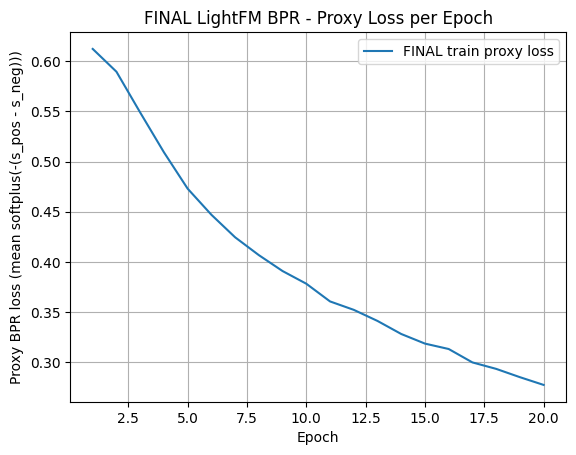

In [ ]:
# ===== Config riêng cho FINAL loss tracking =====
FINAL_EPOCHS = EPOCHS
FINAL_LOSS_SAMPLES = 20000   # tăng nếu muốn curve mượt hơn (vd 30k-50k)

def predict_scores_user_any(model, u_idx, item_indices):
    U = model.user_embeddings
    V = model.item_embeddings
    ub = model.user_biases
    ib = model.item_biases
    return (V[item_indices] @ U[u_idx]) + ib[item_indices] + ub[u_idx]

def compute_bpr_loss_proxy_any(model, pos_list, seen_sets, n_users, n_items,
                               n_samples=20000, seed=42, max_tries=60):
    rng = np.random.default_rng(seed)
    users_with_pos = np.array([u for u in range(n_users) if len(pos_list[u]) > 0], dtype=np.int32)
    if len(users_with_pos) == 0:
        return np.nan, 0

    losses = []
    used = 0

    for _ in range(n_samples):
        u = int(rng.choice(users_with_pos))
        pos_items = pos_list[u]
        i_pos = int(rng.choice(pos_items))

        seen = seen_sets[u]
        i_neg = None
        for __ in range(max_tries):
            j = int(rng.integers(0, n_items))
            if (j != i_pos) and (j not in seen):
                i_neg = j
                break
        if i_neg is None:
            continue

        s_pos = float(predict_scores_user_any(model, u, np.array([i_pos], dtype=np.int32))[0])
        s_neg = float(predict_scores_user_any(model, u, np.array([i_neg], dtype=np.int32))[0])
        diff = s_pos - s_neg
        loss = float(np.logaddexp(0.0, -diff))  # softplus(-diff)

        losses.append(loss)
        used += 1

    if used == 0:
        return np.nan, 0
    return float(np.mean(losses)), used


# ===== Prepare pos/seen from FINAL interactions =====
with Timer("Prepare FINAL pos/seen"):
    final_pos_list = build_pos_list_from_csr(interactions_full)
    final_seen_sets = build_seen_sets(final_pos_list)

# ===== Re-init FINAL model (quan trọng để curve đúng từ epoch 1) =====
set_seed(SEED)
final_model = LightFM(
    loss="bpr",
    no_components=NO_COMPONENTS,
    learning_rate=LEARNING_RATE,
    item_alpha=ITEM_ALPHA,
    user_alpha=USER_ALPHA,
    random_state=SEED
)

final_loss_curve = []
final_epochs_axis = []

with Timer("Train FINAL (epoch loop) + proxy loss"):
    for ep in range(1, FINAL_EPOCHS + 1):
        final_model.fit_partial(
            interactions_full,
            sample_weight=(None if USE_BINARY_INTERACTIONS else weights_full),
            epochs=1,
            num_threads=NUM_THREADS
        )

        loss, used = compute_bpr_loss_proxy_any(
            final_model,
            pos_list=final_pos_list,
            seen_sets=final_seen_sets,
            n_users=final_n_users,
            n_items=final_n_items,
            n_samples=FINAL_LOSS_SAMPLES,
            seed=SEED + 100_000 + ep
        )

        final_epochs_axis.append(ep)
        final_loss_curve.append(loss)
        print(f"[FINAL] Epoch {ep:03d}/{FINAL_EPOCHS} | proxy_loss={loss:.5f} (used={used})")

# ===== Plot FINAL loss =====
plt.figure()
plt.plot(final_epochs_axis, final_loss_curve, label="FINAL train proxy loss")
plt.xlabel("Epoch")
plt.ylabel("Proxy BPR loss (mean softplus(-(s_pos - s_neg)))")
plt.title("FINAL LightFM BPR - Proxy Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()
